# Notebook 07 — Algoritmo Genético + LinearSVC
**Desempenho Socioeconômico no ENEM (2012–2024)**

KNN atingiu teto de performance com Macro F1 marginal. LinearSVC é mais adequado para features
categóricas ordinais codificadas e escala bem sobre 300k amostras.

O Algoritmo Genético (AG) otimiza dois hiperparâmetros do LinearSVC:
- `log₁₀(C)`: controla regularização (menos regularização = modelo mais flexível)
- `class_weight`: None vs 'balanced' (compensa desbalanceamento de classes)

**Estratégia de avaliação de fitness:**
Cada indivíduo é avaliado com um **subset de 30k amostras** para manter cada avaliação em ~1s.
O modelo final é treinado com os melhores parâmetros no conjunto de treino completo (300k).

| Seção | Conteúdo |
|---|---|
| 0 | Setup e configuração |
| 1 | Carregamento via DuckDB |
| 2 | Pré-processamento e split |
| 3 | Componentes do Algoritmo Genético |
| 4 | AG — Modelo M2 (ENEM + IDHM) |
| 5 | AG — Modelo M1 (ENEM only) |
| 6 | Modelos finais e comparação |
| 7 | Figuras e persistência |

## Seção 0 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import gc
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import duckdb

from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── Caminhos ──────────────────────────────────────────────────────────────────
DATA_DIR   = '../data/processed'
MODELS_DIR = '../data/models'
FIGS_DIR   = DATA_DIR
PARQUET    = f'{DATA_DIR}/dataset_analitico.parquet'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Dados ─────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_SAMPLE     = 500_000

FAIXA_ORDER   = ['Baixo (<500)', 'Médio (500–700)', 'Alto (>700)']
FAIXA_MAP_INV = {0: 'Baixo (<500)', 1: 'Médio (500–700)', 2: 'Alto (>700)'}

# ── Algoritmo Genético ────────────────────────────────────────────────────────
GA_POP    = 25        # tamanho da população
GA_GENS   = 20        # número de gerações
GA_CXPB   = 0.70     # probabilidade de crossover
GA_MUTPB  = 0.25     # probabilidade de mutação (por indivíduo)
GA_TOUR   = 3        # tamanho do torneio
GA_ELITE  = 2        # indivíduos elitistas mantidos por geração
GA_SUB    = 30_000   # subset para avaliação de fitness (velocidade)
GA_SEED   = 42

# Espaço de busca: [log10(C), class_weight_balanced]
# gene[0]: log10(C) ∈ [-3, 2]  →  C ∈ [0.001, 100]
# gene[1]: 0=None, 1=balanced  (valor real arredondado)
GENE_MIN = np.array([-3.0, 0.0])
GENE_MAX = np.array([ 2.0, 1.0])
N_GENES  = 2

print('Configuração OK')
print(f'  AG: pop={GA_POP}, gens={GA_GENS}, subset_fitness={GA_SUB:,}')
print(f'  Busca: log10(C) ∈ [{GENE_MIN[0]}, {GENE_MAX[0]}], class_weight ∈ {{None, balanced}}')

Configuração OK
  AG: pop=25, gens=20, subset_fitness=30,000
  Busca: log10(C) ∈ [-3.0, 2.0], class_weight ∈ {None, balanced}


## Seção 1 — Carregamento via DuckDB

Mesmo pipeline do notebook 06: DuckDB lê, filtra, mapeia 6→3 classes e amostra 500k.
Pandas nunca carrega mais de 500k linhas.

In [2]:
con = duckdb.connect()
df = con.execute(f"""
    SELECT
        TP_SEXO, TP_COR_RACA, TP_ESCOLA, Q001, Q002, Q006_HARM,
        REGIAO, CAST(NU_ANO AS INTEGER) AS NU_ANO,
        idhm, idhm_educacao, idhm_renda, idhm_longevidade,
        renda_percapita, tx_analfabetismo, tx_envelhecimento,
        esperanca_vida, mortalidade_infantil,
        -- Questões socioeconômicas estendidas (2019-2024)
        Q_OCUP_PAI, Q_OCUP_MAE, Q_N_PESSOAS,
        Q_EMPREGADA, Q_CARRO, Q_MOTO, Q_GELADEIRA,
        Q_LAVADORA, Q_TV, Q_COMPUTADOR, Q_INTERNET,
        Q_CELULAR, Q_TIPO_ESCOLA_EM, Q_BOLSA_FAM,
        CASE
            WHEN FAIXA_MT IN ('<400', '400-500')    THEN 0
            WHEN FAIXA_MT IN ('500-600', '600-700') THEN 1
            WHEN FAIXA_MT IN ('700-800', '>800')    THEN 2
        END::TINYINT AS y_mt
    FROM read_parquet('{PARQUET}')
    WHERE idhm IS NOT NULL AND FAIXA_MT IS NOT NULL
    USING SAMPLE reservoir({N_SAMPLE} ROWS) REPEATABLE ({RANDOM_STATE})
""").df()
con.close()

print(f'Amostra: {len(df):,} registros')
print('Distribuição y_mt:')
for code, label in FAIXA_MAP_INV.items():
    n = (df['y_mt'] == code).sum()
    print(f'  {label}: {n:,} ({n/len(df)*100:.1f}%)')


Amostra: 139,027 registros
Distribuição y_mt:
  Baixo (<500): 72,719 (52.3%)
  Médio (500–700): 56,457 (40.6%)
  Alto (>700): 9,851 (7.1%)


## Seção 2 — Pré-processamento e Split

In [3]:
SEXO_MAP   = {'F': 0, '0': 0, 'M': 1, '1': 1}
LETTER_MAP = {c: i for i, c in enumerate('ABCDEFGHI')}
INCOME_MAP = {c: i for i, c in enumerate('ABCDE')}
REGIAO_MAP = {'Norte': 0, 'Nordeste': 1, 'Centro-Oeste': 2, 'Sul': 3, 'Sudeste': 4}

df['tp_sexo']   = df['TP_SEXO'].map(SEXO_MAP)
df['tp_cor']    = pd.to_numeric(df['TP_COR_RACA'], errors='coerce')
df['tp_escola'] = pd.to_numeric(df['TP_ESCOLA'], errors='coerce')
df['q001']      = df['Q001'].map(LETTER_MAP)
df['q002']      = df['Q002'].map(LETTER_MAP)
df['q006']      = df['Q006_HARM'].map(INCOME_MAP)
df['regiao']    = df['REGIAO'].map(REGIAO_MAP)
df['ano']       = df['NU_ANO'].astype('float32')

# Encoding Q estendidas
def ord_map(col, letters='ABCDE'):
    return df[col].map({c: i for i, c in enumerate(letters)})

df['q_ocup_pai']      = ord_map('Q_OCUP_PAI',       'ABCDE')
df['q_ocup_mae']      = ord_map('Q_OCUP_MAE',        'ABCDE')
df['q_n_pessoas']     = pd.to_numeric(df['Q_N_PESSOAS'], errors='coerce')
df['q_empregada']     = df['Q_EMPREGADA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_carro']         = ord_map('Q_CARRO',           'ABCD')
df['q_moto']          = ord_map('Q_MOTO',            'ABC')
df['q_geladeira']     = df['Q_GELADEIRA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_lavadora']      = df['Q_LAVADORA'].map({'A': 0, 'B': 1, 'C': 2})
df['q_tv']            = ord_map('Q_TV',              'ABCD')
df['q_computador']    = ord_map('Q_COMPUTADOR',      'ABCD')
df['q_internet']      = df['Q_INTERNET'].map({'A': 0, 'B': 1, 'C': 2})
df['q_celular']       = ord_map('Q_CELULAR',         'ABCDE')
df['q_tipo_esc_em']   = ord_map('Q_TIPO_ESCOLA_EM',  'ABCDE')
df['q_bolsa_fam']     = df['Q_BOLSA_FAM'].map({'A': 0, 'B': 1, 'C': 2})

FEATS_BASE = ['tp_sexo', 'tp_cor', 'tp_escola', 'q001', 'q002', 'q006', 'regiao', 'ano']
FEATS_IDHM = [
    'idhm', 'idhm_educacao', 'idhm_renda', 'idhm_longevidade',
    'renda_percapita', 'tx_analfabetismo', 'tx_envelhecimento',
    'esperanca_vida', 'mortalidade_infantil'
]
FEATS_Q_EXT = [
    'q_ocup_pai', 'q_ocup_mae', 'q_n_pessoas', 'q_empregada',
    'q_carro', 'q_moto', 'q_geladeira', 'q_lavadora', 'q_tv',
    'q_computador', 'q_internet', 'q_celular', 'q_tipo_esc_em', 'q_bolsa_fam'
]
FEATS_M1 = FEATS_BASE
FEATS_M2 = FEATS_BASE + FEATS_IDHM
FEATS_M3 = FEATS_BASE + FEATS_Q_EXT
FEATS_M4 = FEATS_BASE + FEATS_IDHM + FEATS_Q_EXT

print(f'M1: {len(FEATS_M1)} | M2: {len(FEATS_M2)} | M3: {len(FEATS_M3)} | M4: {len(FEATS_M4)} features')


M1: 8 | M2: 17 | M3: 22 | M4: 31 features


In [4]:
X_m1 = df[FEATS_M1].values.astype('float32')
X_m2 = df[FEATS_M2].values.astype('float32')
X_m3 = df[FEATS_M3].values.astype('float32')
X_m4 = df[FEATS_M4].values.astype('float32')
y    = df['y_mt'].values.astype('int8')
del df; gc.collect()

# Split 60/20/20
(Xm1_tmp, Xm1_test, Xm2_tmp, Xm2_test,
 Xm3_tmp, Xm3_test, Xm4_tmp, Xm4_test,
 y_tmp, y_test) = train_test_split(
    X_m1, X_m2, X_m3, X_m4, y,
    test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
(Xm1_train, Xm1_val, Xm2_train, Xm2_val,
 Xm3_train, Xm3_val, Xm4_train, Xm4_val,
 y_train, y_val) = train_test_split(
    Xm1_tmp, Xm2_tmp, Xm3_tmp, Xm4_tmp, y_tmp,
    test_size=0.25, stratify=y_tmp, random_state=RANDOM_STATE
)
del Xm1_tmp, Xm2_tmp, Xm3_tmp, Xm4_tmp, y_tmp; gc.collect()

# Subsets estratificados para fitness do AG
(_, Xm1_sub, _, Xm2_sub, _, Xm3_sub, _, Xm4_sub,
 _, y_sub) = train_test_split(
    Xm1_train, Xm2_train, Xm3_train, Xm4_train, y_train,
    test_size=GA_SUB, stratify=y_train, random_state=RANDOM_STATE
)
(_, Xm1_subval, _, Xm2_subval, _, Xm3_subval, _, Xm4_subval,
 _, y_subval) = train_test_split(
    Xm1_val, Xm2_val, Xm3_val, Xm4_val, y_val,
    test_size=min(10_000, len(y_val)), stratify=y_val, random_state=RANDOM_STATE
)

print(f'Train: {len(y_train):,} | Val: {len(y_val):,} | Test: {len(y_test):,} [SELADO]')
print(f'Subset AG — treino: {len(y_sub):,} | val: {len(y_subval):,}')


Train: 83,415 | Val: 27,806 | Test: 27,806 [SELADO]
Subset AG — treino: 30,000 | val: 10,000


## Seção 3 — Componentes do Algoritmo Genético

Implementação do AG real-valued do zero (sem bibliotecas externas).

| Operador | Estratégia |
|---|---|
| Seleção | Torneio (k=3) |
| Crossover | Uniforme (troca gene a gene com p=0.5) |
| Mutação | Gaussiana no gene contínuo, flip no gene binário |
| Elitismo | Top-2 indivíduos passam direto para a próxima geração |

In [5]:
def make_svm_pipeline(C, balanced):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('svm',     LinearSVC(
            C=C,
            class_weight='balanced' if balanced else None,
            max_iter=2000,
            random_state=RANDOM_STATE
        ))
    ])


def decode(ind):
    """Chromosome → SVM params."""
    C        = float(10 ** np.clip(ind[0], GENE_MIN[0], GENE_MAX[0]))
    balanced = bool(round(float(np.clip(ind[1], 0.0, 1.0))))
    return C, balanced


def fitness(ind, X_tr, X_v, y_tr, y_v):
    C, balanced = decode(ind)
    try:
        pipe = make_svm_pipeline(C, balanced)
        pipe.fit(X_tr, y_tr)
        yp = pipe.predict(X_v)
        return f1_score(y_v, yp, average='macro')
    except Exception:
        return 0.0


def init_pop(rng):
    pop = np.column_stack([
        rng.uniform(GENE_MIN[0], GENE_MAX[0], GA_POP),   # log10(C)
        rng.integers(0, 2, GA_POP).astype(float),        # class_weight
    ])
    return pop


def tournament(pop, fits, rng):
    idx = rng.integers(0, len(pop), GA_TOUR)
    return pop[idx[np.argmax(fits[idx])]].copy()


def crossover(p1, p2, rng):
    mask = rng.random(N_GENES) < 0.5
    return np.where(mask, p1, p2), np.where(mask, p2, p1)


def mutate(ind, rng):
    ind = ind.copy()
    if rng.random() < 0.4:                          # mutação gene 0 (contínuo)
        ind[0] = np.clip(ind[0] + rng.normal(0, 0.6), GENE_MIN[0], GENE_MAX[0])
    if rng.random() < 0.3:                          # mutação gene 1 (binário)
        ind[1] = 1.0 - ind[1]
    return ind


def evolve(X_tr, X_v, y_tr, y_v, label=''):
    """Roda o AG completo. Retorna (melhor_individuo, melhor_fitness, historico)."""
    rng = np.random.default_rng(GA_SEED)
    pop = init_pop(rng)
    fits = np.array([fitness(ind, X_tr, X_v, y_tr, y_v) for ind in pop])

    history = [fits.max()]
    best_idx = fits.argmax()
    C0, b0 = decode(pop[best_idx])
    print(f'[{label}] Gen 0 — best F1={fits.max():.4f} (C={C0:.4f}, balanced={b0})')

    for gen in range(1, GA_GENS + 1):
        elite_idx = np.argsort(fits)[-GA_ELITE:]
        new_pop   = list(pop[elite_idx])

        while len(new_pop) < GA_POP:
            p1, p2 = tournament(pop, fits, rng), tournament(pop, fits, rng)
            c1, c2 = (crossover(p1, p2, rng) if rng.random() < GA_CXPB
                      else (p1.copy(), p2.copy()))
            if rng.random() < GA_MUTPB: c1 = mutate(c1, rng)
            if rng.random() < GA_MUTPB: c2 = mutate(c2, rng)
            new_pop.append(c1)
            if len(new_pop) < GA_POP:
                new_pop.append(c2)

        pop  = np.array(new_pop)
        fits = np.array([fitness(ind, X_tr, X_v, y_tr, y_v) for ind in pop])
        history.append(fits.max())

        best_idx = fits.argmax()
        C_best, b_best = decode(pop[best_idx])
        print(f'[{label}] Gen {gen:2d} — best F1={fits.max():.4f}  '
              f'(C={C_best:.4f}, balanced={b_best})  mean={fits.mean():.4f}')

    best_idx = fits.argmax()
    return pop[best_idx], fits[best_idx], history


print('Componentes do AG definidos.')

Componentes do AG definidos.


## Seção 4 — AG: Modelo M2 (ENEM + IDHM)

Primeiro roda o AG com todas as features (M2) — inclui indicadores IDHM estaduais.
Fitness avaliado no subset de 30k treino × 10k validação.

In [6]:
print('=== AG — Modelo M2 (ENEM + IDHM) ===')
t0 = time.time()

best_ind_m2, best_fit_m2, history_m2 = evolve(
    Xm2_sub, Xm2_subval, y_sub, y_subval, label='M2'
)

best_C_m2, best_bal_m2 = decode(best_ind_m2)
print(f'\nResultado M2: C={best_C_m2:.4f}, balanced={best_bal_m2}')
print(f'Fitness (Macro F1 no subset): {best_fit_m2:.4f}')
print(f'Tempo total: {(time.time()-t0)/60:.1f} min')

=== AG — Modelo M2 (ENEM + IDHM) ===
[M2] Gen 0 — best F1=0.4740 (C=43.0353, balanced=True)
[M2] Gen  1 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4533
[M2] Gen  2 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4570
[M2] Gen  3 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4572
[M2] Gen  4 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4740
[M2] Gen  5 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4672
[M2] Gen  6 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4706
[M2] Gen  7 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4740
[M2] Gen  8 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4672
[M2] Gen  9 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4672
[M2] Gen 10 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4740
[M2] Gen 11 — best F1=0.4740  (C=24.5278, balanced=True)  mean=0.4739
[M2] Gen 12 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.4705
[M2] Gen 13 — best F1=0.4740  (C=43.0353, balanced=True)  mean=0.474

## Seção 5 — AG: Modelo M1 (ENEM only)

In [7]:
print('=== AG — Modelo M1 (ENEM only) ===')
t0 = time.time()

best_ind_m1, best_fit_m1, history_m1 = evolve(
    Xm1_sub, Xm1_subval, y_sub, y_subval, label='M1'
)

best_C_m1, best_bal_m1 = decode(best_ind_m1)
print(f'\nResultado M1: C={best_C_m1:.4f}, balanced={best_bal_m1}')
print(f'Fitness (Macro F1 no subset): {best_fit_m1:.4f}')
print(f'Tempo total: {(time.time()-t0)/60:.1f} min')

=== AG — Modelo M1 (ENEM only) ===
[M1] Gen 0 — best F1=0.4709 (C=7.4094, balanced=True)
[M1] Gen  1 — best F1=0.4709  (C=0.0030, balanced=True)  mean=0.4511
[M1] Gen  2 — best F1=0.4709  (C=0.0030, balanced=True)  mean=0.4544
[M1] Gen  3 — best F1=0.4709  (C=0.0026, balanced=True)  mean=0.4544
[M1] Gen  4 — best F1=0.4710  (C=0.0021, balanced=True)  mean=0.4709
[M1] Gen  5 — best F1=0.4710  (C=0.0021, balanced=True)  mean=0.4643
[M1] Gen  6 — best F1=0.4710  (C=0.0026, balanced=True)  mean=0.4677
[M1] Gen  7 — best F1=0.4710  (C=0.0021, balanced=True)  mean=0.4710
[M1] Gen  8 — best F1=0.4710  (C=0.0021, balanced=True)  mean=0.4644
[M1] Gen  9 — best F1=0.4710  (C=0.0021, balanced=True)  mean=0.4644
[M1] Gen 10 — best F1=0.4710  (C=0.0026, balanced=True)  mean=0.4710
[M1] Gen 11 — best F1=0.4710  (C=0.0026, balanced=True)  mean=0.4710
[M1] Gen 12 — best F1=0.4710  (C=0.0021, balanced=True)  mean=0.4677
[M1] Gen 13 — best F1=0.4710  (C=0.0026, balanced=True)  mean=0.4710
[M1] Gen 14 — 

## Seção 6 — Modelos Finais e Comparação

Treina os modelos finais com os melhores hiperparâmetros encontrados pelo AG,
agora sobre o conjunto de treino completo (300k amostras).

In [8]:
print(f'=== Modelo Final M2: C={best_C_m2:.4f}, balanced={best_bal_m2} ===')
pipe_svm_m2 = make_svm_pipeline(best_C_m2, best_bal_m2)
pipe_svm_m2.fit(Xm2_train, y_train)
yp_svm_m2 = pipe_svm_m2.predict(Xm2_val)

svm_m2_metrics = {
    'Accuracy'   : accuracy_score(y_val, yp_svm_m2),
    'Macro F1'   : f1_score(y_val, yp_svm_m2, average='macro'),
    'Weighted F1': f1_score(y_val, yp_svm_m2, average='weighted'),
}
print('Métricas M2 no validation set (300k treino):')
for k, v in svm_m2_metrics.items():
    print(f'  {k:<15s}: {v:.4f}')

print('\nClassification Report M2:')
print(classification_report(y_val, yp_svm_m2, target_names=FAIXA_ORDER))

=== Modelo Final M2: C=43.0353, balanced=True ===
Métricas M2 no validation set (300k treino):
  Accuracy       : 0.5453
  Macro F1       : 0.4717
  Weighted F1    : 0.5371

Classification Report M2:
                 precision    recall  f1-score   support

   Baixo (<500)       0.64      0.72      0.68     14544
Médio (500–700)       0.49      0.32      0.39     11292
    Alto (>700)       0.26      0.54      0.35      1970

       accuracy                           0.55     27806
      macro avg       0.46      0.53      0.47     27806
   weighted avg       0.55      0.55      0.54     27806



In [9]:
print(f'=== Modelo Final M1: C={best_C_m1:.4f}, balanced={best_bal_m1} ===')
pipe_svm_m1 = make_svm_pipeline(best_C_m1, best_bal_m1)
pipe_svm_m1.fit(Xm1_train, y_train)
yp_svm_m1 = pipe_svm_m1.predict(Xm1_val)

svm_m1_metrics = {
    'Accuracy'   : accuracy_score(y_val, yp_svm_m1),
    'Macro F1'   : f1_score(y_val, yp_svm_m1, average='macro'),
    'Weighted F1': f1_score(y_val, yp_svm_m1, average='weighted'),
}
print('Métricas M1 no validation set (300k treino):')
for k, v in svm_m1_metrics.items():
    print(f'  {k:<15s}: {v:.4f}')

print('\nClassification Report M1:')
print(classification_report(y_val, yp_svm_m1, target_names=FAIXA_ORDER))

=== Modelo Final M1: C=0.0016, balanced=True ===
Métricas M1 no validation set (300k treino):
  Accuracy       : 0.5403
  Macro F1       : 0.4660
  Weighted F1    : 0.5313

Classification Report M1:
                 precision    recall  f1-score   support

   Baixo (<500)       0.64      0.72      0.68     14544
Médio (500–700)       0.48      0.31      0.38     11292
    Alto (>700)       0.25      0.54      0.34      1970

       accuracy                           0.54     27806
      macro avg       0.46      0.52      0.47     27806
   weighted avg       0.55      0.54      0.53     27806



In [10]:
rows = [
    ('LinearSVC+AG — ENEM only',  best_C_m1, best_bal_m1,
     svm_m1_metrics['Accuracy'], svm_m1_metrics['Macro F1'], svm_m1_metrics['Weighted F1']),
    ('LinearSVC+AG — ENEM+IDHM',  best_C_m2, best_bal_m2,
     svm_m2_metrics['Accuracy'], svm_m2_metrics['Macro F1'], svm_m2_metrics['Weighted F1']),
]
df_res = pd.DataFrame(rows,
    columns=['Modelo', 'C', 'balanced', 'Accuracy', 'Macro F1', 'Weighted F1'])

print('=== Tabela Comparativa — FAIXA_MT 3 classes (validation set) ===')
print(df_res.to_string(index=False))

delta_f1 = svm_m2_metrics['Macro F1'] - svm_m1_metrics['Macro F1']
print(f'\nΔ Macro F1 (M2 − M1): {delta_f1:+.4f}')

=== Tabela Comparativa — FAIXA_MT 3 classes (validation set) ===
                  Modelo         C  balanced  Accuracy  Macro F1  Weighted F1
LinearSVC+AG — ENEM only  0.001610      True  0.540279  0.466001     0.531306
LinearSVC+AG — ENEM+IDHM 43.035311      True  0.545278  0.471724     0.537092

Δ Macro F1 (M2 − M1): +0.0057


## Seção 7 — Figuras e Persistência

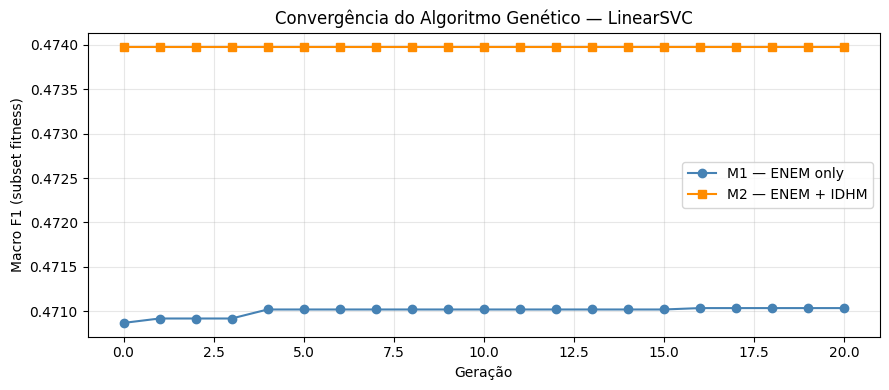

Figura salva: fig_ga_convergencia.png


In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
gens = range(GA_GENS + 1)
ax.plot(gens, history_m1, 'o-', color='steelblue',  label='M1 — ENEM only')
ax.plot(gens, history_m2, 's-', color='darkorange', label='M2 — ENEM + IDHM')

ax.set_xlabel('Geração')
ax.set_ylabel('Macro F1 (subset fitness)')
ax.set_title('Convergência do Algoritmo Genético — LinearSVC')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_ga_convergencia.png', dpi=150)
plt.show()
print('Figura salva: fig_ga_convergencia.png')

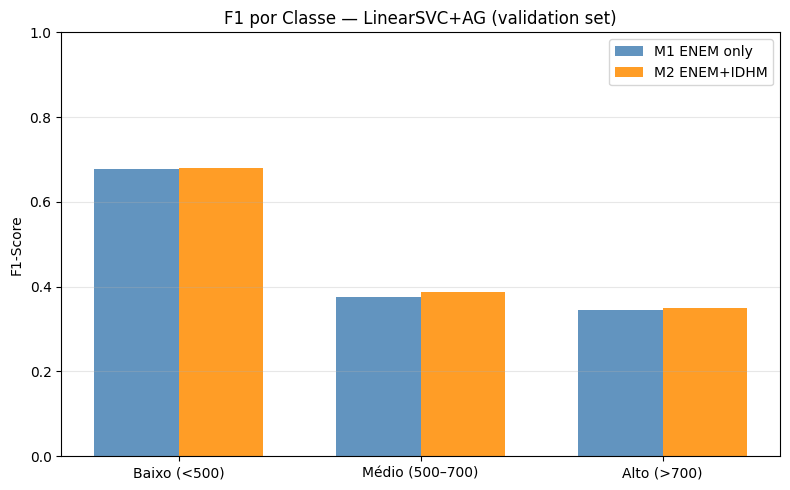

Figura salva: fig_svm_f1_classe.png


In [12]:
from sklearn.metrics import f1_score as f1

f1_m1 = f1(y_val, yp_svm_m1, average=None, labels=[0, 1, 2])
f1_m2 = f1(y_val, yp_svm_m2, average=None, labels=[0, 1, 2])

x = np.arange(3)
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, f1_m1, w, label='M1 ENEM only', color='steelblue',  alpha=0.85)
ax.bar(x + w/2, f1_m2, w, label='M2 ENEM+IDHM', color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FAIXA_ORDER)
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1)
ax.set_title('F1 por Classe — LinearSVC+AG (validation set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_svm_f1_classe.png', dpi=150)
plt.show()
print('Figura salva: fig_svm_f1_classe.png')

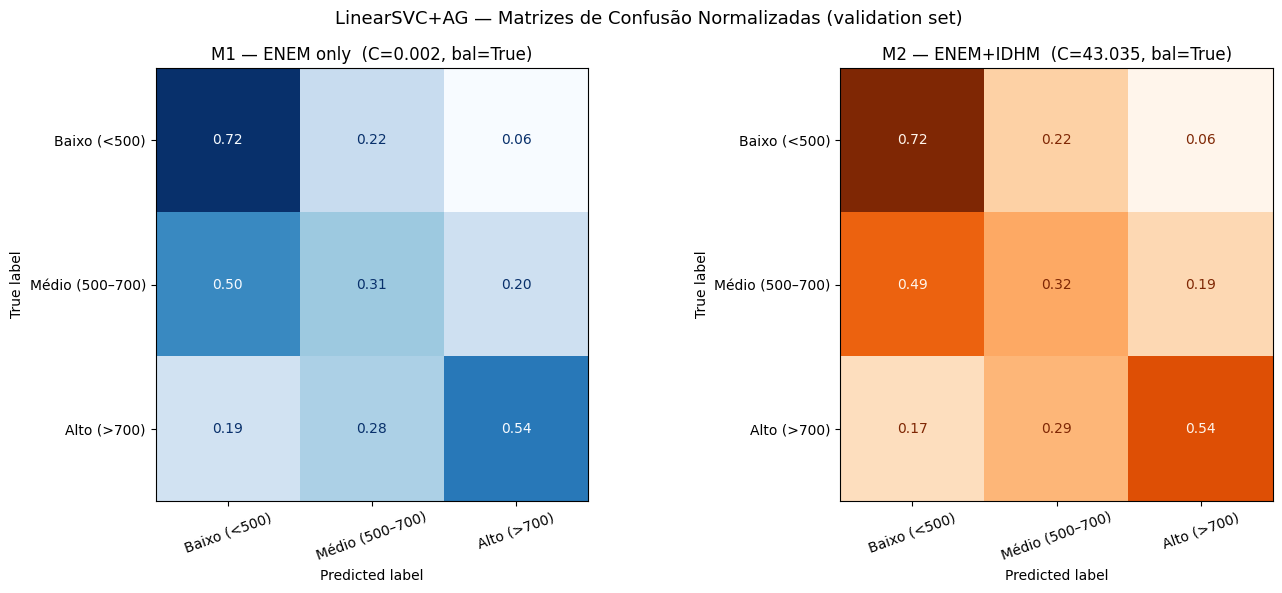

Figura salva: fig_svm_cm_comparativo.png


In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_m1 = confusion_matrix(y_val, yp_svm_m1, normalize='true')
cm_m2 = confusion_matrix(y_val, yp_svm_m2, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cm, title, cmap in zip(
    axes,
    [cm_m1, cm_m2],
    [f'M1 — ENEM only  (C={best_C_m1:.3f}, bal={best_bal_m1})',
     f'M2 — ENEM+IDHM  (C={best_C_m2:.3f}, bal={best_bal_m2})'],
    ['Blues', 'Oranges']
):
    disp = ConfusionMatrixDisplay(cm, display_labels=FAIXA_ORDER)
    disp.plot(ax=ax, cmap=cmap, colorbar=False, values_format='.2f')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)

fig.suptitle('LinearSVC+AG — Matrizes de Confusão Normalizadas (validation set)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGS_DIR}/fig_svm_cm_comparativo.png', dpi=150)
plt.show()
print('Figura salva: fig_svm_cm_comparativo.png')

In [14]:
joblib.dump(pipe_svm_m1, f'{MODELS_DIR}/svm_ga_enem_only_faixa_mt.pkl')
joblib.dump(pipe_svm_m2, f'{MODELS_DIR}/svm_ga_enem_idhm_faixa_mt.pkl')
print('Modelos salvos em data/models/')

# Salva também os parâmetros encontrados pelo AG
ag_results = {
    'm1': {'C': best_C_m1, 'balanced': best_bal_m1, 'fitness': best_fit_m1, 'history': history_m1},
    'm2': {'C': best_C_m2, 'balanced': best_bal_m2, 'fitness': best_fit_m2, 'history': history_m2},
    'val_metrics': {'m1': svm_m1_metrics, 'm2': svm_m2_metrics},
}
joblib.dump(ag_results, f'{MODELS_DIR}/ag_results.pkl')
print('Resultados do AG salvos: data/models/ag_results.pkl')

print('\n=== RESUMO FINAL ===')
print(df_res.to_string(index=False))

Modelos salvos em data/models/
Resultados do AG salvos: data/models/ag_results.pkl

=== RESUMO FINAL ===
                  Modelo         C  balanced  Accuracy  Macro F1  Weighted F1
LinearSVC+AG — ENEM only  0.001610      True  0.540279  0.466001     0.531306
LinearSVC+AG — ENEM+IDHM 43.035311      True  0.545278  0.471724     0.537092
